# **Labeling – Fahrbahnoberfläche des Testdatensatzes**

Dieses Notebook dient dem **manuellen Labeln** der Bilder in
[`dataset/testdataset/`](../dataset/testdataset). Die Labels bilden die *Ground Truth*, um die
automatische Zero-Shot-Klassifikation aus
[`road_detection.ipynb`](../research/road_detection.ipynb) bzw.
[`ground_detection.ipynb`](../research/ground_detection.ipynb)
zu evaluieren.

**Ablauf (Tastatur-Labeling):**

1. Zellen der Reihe nach ausführen.
2. In der Labeling-Zelle die **Maus über das Bild** halten und die zum Label passende **Zahlentaste** drücken.
3. Das Label wird sofort vergeben, automatisch in eine CSV gespeichert und das nächste Bild angezeigt.

**Label-Klassen** (konsistent zu `road_detection.ipynb`) und **Tastenbelegung**:

| Taste | Klasse | Komfort/Qualität $O_{surf}$ |
| :---: | ------ | :---: |
| `1` | Cycleway (asphaltierter Radweg) | 1.00 |
| `2` | Road (asphaltierte Straße) | 0.95 |
| `3` | Gravel (Kies/Schotter) | 0.25 |
| `4` | Unpaved (Erde/Feldweg) | 0.15 |
| `5` | Unklar/Sonstige | – |

**Navigation:** `s` oder `→` überspringt ein Bild · `z` oder `←` geht ein Bild zurück (Korrektur).

**Speicherung (Best Practice):** Die Labels landen in einer **CSV-Datei**
(`evaluate/labels_testdataset.csv`) – ein pro Bild, mit Zeitstempel. Das ist versionierbar,
menschenlesbar und **resümierbar**: Bereits gelabelte Bilder werden beim Neustart automatisch
übersprungen, und jedes Label wird sofort gespeichert (crash-sicher).

> **Hinweis:** Nach dem Wechsel auf das neue 4-Klassen-Schema stammen bereits vorhandene Labels
> (`Asphalt/Beton`, `Schotter/Kies` …) noch aus dem alten Schema. Zum vollständigen Neu-Labeln die alte
> `labels_testdataset.csv` löschen bzw. umbenennen, damit alle Bilder erneut abgefragt werden.


## 1. Setup & Imports

Für das interaktive Tastatur-Labeling nutzen wir `ipywidgets` (Anzeige) und `ipyevents`
(Tastatur-Events im Notebook). Beide bei Bedarf einmalig installieren – dazu die
Kommentarzeile unten aktivieren und die Zelle ausführen.


In [1]:
# Einmalige Installation (nur beim ersten Mal nötig) – Kommentar entfernen und ausführen:
# %pip install ipywidgets ipyevents matplotlib

import csv
import datetime as dt
from collections import Counter
from pathlib import Path

import ipywidgets as widgets
from IPython.display import display
from ipyevents import Event

print("Setup abgeschlossen.")


Setup abgeschlossen.


## 2. Konfiguration

Das Notebook liegt in `evaluate/`, die Bilder daher relativ unter `../dataset/testdataset/`.
Die Label-Klassen und ihre Qualitätswerte entsprechen `road_detection.ipynb`
(`Cycleway`, `Road`, `Gravel`, `Unpaved`). Die Tastenbelegung ordnet jeder Klasse eine
Zahlentaste zu (`5` = *Unklar/Sonstige*).


In [2]:
# Ordner mit den zu labelnden Bildern (Notebook liegt in evaluate/)
TESTDATASET_DIR = Path("../dataset/testdataset")

# Ausgabedatei für die Labels (CSV: einfach, versionierbar, resümierbar)
LABELS_CSV = Path("labels_testdataset.csv")

# Label-Klassen konsistent zu road_detection.ipynb (vier Oberflächen + "Unklar/Sonstige").
# Taste (str) -> (Klassenname, Komfort/Qualität O_surf in [0,1] oder None)
LABEL_CLASSES: dict[str, tuple[str, float | None]] = {
    "1": ("Cycleway", 1.00),      # asphaltierter Radweg
    "2": ("Road", 0.95),          # asphaltierte/betonierte Straße
    "3": ("Gravel", 0.25),        # Kies / Schotter
    "4": ("Unpaved", 0.15),       # Erde / Feldweg / unbefestigt
    "5": ("Unklar/Sonstige", None),
}

# Steuertasten für die Navigation
KEYS_SKIP = {"s", "ArrowRight"}   # Bild ohne Label überspringen
KEYS_BACK = {"z", "ArrowLeft"}    # ein Bild zurück (zur Korrektur)

# Maximale Anzeigebreite des Bildes im Notebook (Pixel)
DISPLAY_MAX_WIDTH = 900

print("Konfiguration geladen.")
print(f"  Bildordner : {TESTDATASET_DIR.resolve()}")
print(f"  Label-Datei: {LABELS_CSV.resolve()}")
print(f"  Klassen    : {[name for name, _ in LABEL_CLASSES.values()]}")


Konfiguration geladen.
  Bildordner : C:\Users\aydem\Documents\DHBW\computer_vision\computer_vision_bikeability_score\research\ground_detection\dataset\testdataset
  Label-Datei: C:\Users\aydem\Documents\DHBW\computer_vision\computer_vision_bikeability_score\research\ground_detection\evaluate\labels_testdataset.csv
  Klassen    : ['Cycleway', 'Road', 'Gravel', 'Unpaved', 'Unklar/Sonstige']


## 3. Bilder laden & vorhandene Labels einlesen (Resume)

Wir sammeln alle JPGs aus dem Testdatensatz und lesen eine ggf. bereits vorhandene
Label-CSV ein. So kann das Labeling jederzeit **unterbrochen und fortgesetzt** werden – bereits
gelabelte Bilder werden erkannt und beim Start übersprungen.


In [7]:
CSV_FIELDS = ["filename", "video", "label_id", "label", "quality", "timestamp"]


def video_of(filename: str) -> str:
    """Leitet den Video-Namen aus dem Dateinamen ab (DJI_0348_frame_00001.jpg -> DJI_0348)."""
    return "_".join(filename.split("_")[:2])


def load_labels(path: Path) -> dict[str, dict]:
    """Liest vorhandene Labels aus der CSV als {Dateiname: Datensatz}."""
    if not path.exists():
        return {}
    with path.open(newline="", encoding="utf-8") as f:
        return {row["filename"]: row for row in csv.DictReader(f)}


def save_labels(path: Path, labels: dict[str, dict]) -> None:
    """Schreibt alle Labels (nach Dateiname sortiert) in die CSV."""
    with path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=CSV_FIELDS)
        writer.writeheader()
        for filename in sorted(labels):
            writer.writerow(labels[filename])


# Alle Bilder einsammeln und vorhandene Labels laden
all_images = sorted(TESTDATASET_DIR.glob("*.jpg"))
labels = load_labels(LABELS_CSV)

print(f"Bilder gefunden : {len(all_images)}")
print(f"Bereits gelabelt: {len(labels)}")
print(f"Verbleibend     : {len(all_images) - len(labels)}")

if not all_images:
    print(f"\n⚠ Keine JPGs in {TESTDATASET_DIR.resolve()} gefunden.")


Bilder gefunden : 1704
Bereits gelabelt: 1658
Verbleibend     : 46


## 4. Interaktives Tastatur-Labeling

Beim Ausführen der nächsten Zelle erscheint das erste noch ungelabelte Bild. **Maus über das
Bild bewegen** und die passende **Zahlentaste** drücken – das Label wird sofort vergeben,
gespeichert und das nächste Bild geladen.

- `1`–`5` → Klasse vergeben (siehe Legende über dem Bild; `5` = Unklar/Sonstige)
- `s` / `→` → überspringen · `z` / `←` → zurück (Korrektur)

Jedes Label wird **sofort** in `labels_testdataset.csv` geschrieben. Das Labeling kann jederzeit
gestoppt und später (durch erneutes Ausführen dieser Zelle) fortgesetzt werden.


In [12]:
# --- Zustand: aktuelle Position in all_images ---
def first_unlabeled() -> int:
    """Index des ersten noch nicht gelabelten Bildes (sonst 0)."""
    for i, path in enumerate(all_images):
        if path.name not in labels:
            return i
    return 0


state = {"pos": first_unlabeled()}

# --- Widgets ---
legend_html = (
    "<b>Tasten:</b> "
    + " &nbsp; ".join(
        f"<code>{key}</code>&nbsp;{name}" for key, (name, _) in LABEL_CLASSES.items()
    )
    + " &nbsp;|&nbsp; <code>s</code>/→ überspringen &nbsp; <code>z</code>/← zurück"
    + "<br><i>Auf einen Button klicken – oder ins Bild klicken und dann eine Zahlentaste drücken.</i>"
)
legend = widgets.HTML(legend_html)
progress = widgets.HTML()
img_widget = widgets.Image(
    format="jpg",
    layout=widgets.Layout(max_width=f"{DISPLAY_MAX_WIDTH}px", border="1px solid #ccc"),
)


def apply_action(action: str) -> None:
    """Zentrale Aktion für Tastatur UND Buttons: Label vergeben, überspringen, zurück."""
    if not all_images:
        return
    pos = state["pos"]
    path = all_images[pos]

    if action in LABEL_CLASSES:
        name, quality = LABEL_CLASSES[action]
        labels[path.name] = {
            "filename": path.name,
            "video": video_of(path.name),
            "label_id": action,
            "label": name,
            "quality": "" if quality is None else quality,
            "timestamp": dt.datetime.now().isoformat(timespec="seconds"),
        }
        save_labels(LABELS_CSV, labels)  # sofort speichern (crash-sicher)
        state["pos"] = pos + 1
    elif action == "__skip__":
        state["pos"] = pos + 1
    elif action == "__back__":
        state["pos"] = pos - 1
    else:
        return

    render()


# Klickbare Buttons je Klasse (funktionieren immer, auch ohne Tastatur-Fokus)
class_buttons = []
for key, (name, _) in LABEL_CLASSES.items():
    btn = widgets.Button(
        description=f"{key}: {name}",
        layout=widgets.Layout(width="auto"),
        button_style="info",
    )
    btn.on_click(lambda _b, k=key: apply_action(k))
    class_buttons.append(btn)

back_btn = widgets.Button(description="⏪ Zurück (z)")
skip_btn = widgets.Button(description="Überspringen (s) ⏭", button_style="warning")
back_btn.on_click(lambda _b: apply_action("__back__"))
skip_btn.on_click(lambda _b: apply_action("__skip__"))

buttons_row = widgets.HBox(class_buttons)
nav_row = widgets.HBox([back_btn, skip_btn])
box = widgets.VBox([legend, progress, img_widget, buttons_row, nav_row])


def render() -> None:
    """Aktualisiert Bild und Fortschrittsanzeige entsprechend state['pos']."""
    total = len(all_images)
    if total == 0:
        progress.value = "<b>Keine Bilder vorhanden.</b>"
        return

    pos = max(0, min(state["pos"], total - 1))
    state["pos"] = pos
    path = all_images[pos]
    img_widget.value = path.read_bytes()

    done = len(labels)
    rec = labels.get(path.name)
    current = (
        f"<span style='color:green'>Label: <b>{rec['label']}</b></span>"
        if rec
        else "<span style='color:#b00'>noch kein Label</span>"
    )
    finished = " &nbsp;🎉 <b>Alle Bilder gelabelt!</b>" if done == total else ""
    progress.value = (
        f"<b>Bild {pos + 1}/{total}</b> &nbsp;|&nbsp; gelabelt: {done}/{total} "
        f"&nbsp;|&nbsp; <code>{path.name}</code> &nbsp;|&nbsp; {current}{finished}"
    )


def handle_event(event: dict) -> None:
    """Verarbeitet Tastendrücke und leitet sie an apply_action weiter."""
    if event.get("repeat"):  # gedrückt gehaltene Taste ignorieren
        return
    key = event.get("key")
    if key in LABEL_CLASSES:
        apply_action(key)
    elif key in KEYS_SKIP:
        apply_action("__skip__")
    elif key in KEYS_BACK:
        apply_action("__back__")


# Tastatur-Events auf dem Bild-Container abfangen (nach Klick ins Widget aktiv)
listener = Event(source=box, watched_events=["keydown"], prevent_default_action=True)
listener.on_dom_event(handle_event)

render()
display(box)


## 5. Auswertung der vergebenen Labels

Übersicht über den Labeling-Fortschritt und die Verteilung der Oberflächen-Klassen. Diese Zelle
liest die CSV neu ein und kann jederzeit (auch während des Labelns) ausgeführt werden.


Gelabelt: 1704/1704 (100.0%)
----------------------------------------
  Cycleway                     977  (57.3%)
  Road                         486  (28.5%)
  Gravel                        54  ( 3.2%)
  Unpaved                        9  ( 0.5%)
  Unklar/Sonstige              178  (10.4%)


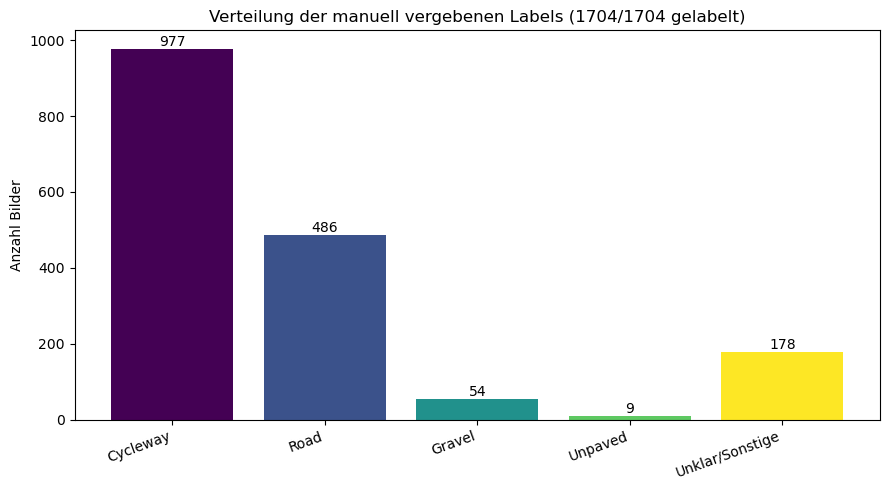

In [10]:
import matplotlib.pyplot as plt

labels = load_labels(LABELS_CSV)
class_names = [name for name, _ in LABEL_CLASSES.values()]
counts = Counter(rec["label"] for rec in labels.values())

total = len(all_images)
done = len(labels)
print(f"Gelabelt: {done}/{total} ({done / total * 100:.1f}%)" if total else "Keine Bilder.")
print("-" * 40)
for name in class_names:
    n = counts.get(name, 0)
    share = n / done * 100 if done else 0
    print(f"  {name:<28}{n:>4}  ({share:4.1f}%)")

# Balkendiagramm der Klassenverteilung
if done:
    values = [counts.get(name, 0) for name in class_names]
    plt.figure(figsize=(9, 5))
    plt.bar(class_names, values, color=plt.get_cmap("viridis")(
        [i / max(len(class_names) - 1, 1) for i in range(len(class_names))]
    ))
    plt.ylabel("Anzahl Bilder")
    plt.title(f"Verteilung der manuell vergebenen Labels ({done}/{total} gelabelt)")
    plt.xticks(rotation=20, ha="right")
    for i, v in enumerate(values):
        plt.text(i, v, str(v), ha="center", va="bottom")
    plt.tight_layout()
    plt.show()
else:
    print("\nNoch keine Labels vergeben.")
